In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [4]:
def f(x):
    return 3*x**2 - 4*x + 5

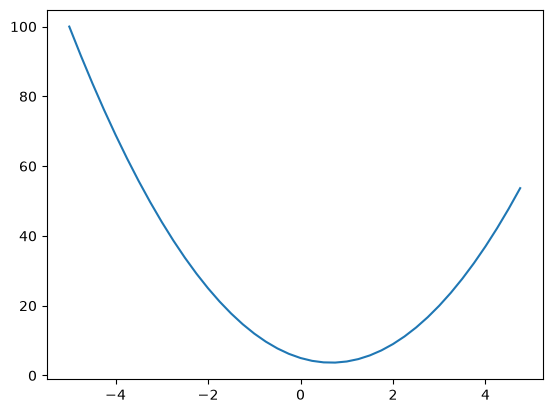

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [6]:
h = 0.0001
x = 3.0
(f(x+h)-f(x))/h

14.000300000063248

In [7]:
a = 2
b = -3
c = 10

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4
d2 4.0001
slope 0.9999999999976694


In [8]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        return Value(self.data+other.data, (self, other), '+')
    def __mul__(self, other):
        return Value(self.data*other.data, (self, other), '*')
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data=-8.0)

In [9]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for to in v._prev:
                edges.add((to, v))
                build(to)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for v in nodes:
        uid = str(id(v))
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (v.label, v.data, v.grad), shape='record')
        if v._op:
            dot.node(name=uid+v._op, label=v._op)
            dot.edge(uid+v._op, uid)
    for v, u in edges:
        dot.edge(str(id(v)), str(id(u)) + u._op)
    return dot

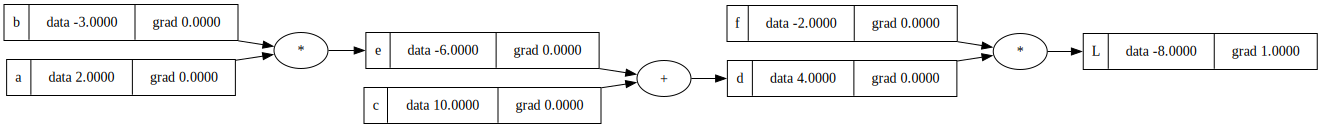

In [19]:
draw_dot(L)

In [18]:
L.grad = 1.0

In [13]:
def lol():
    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L2 = L.data+h

    print((L2-L1)/h)

lol()

1.000000000000334
